## (ML Baselines) Experiment 1 - Binary STAR-GALAXY Classification with RF / SVM / MLP



In [1]:
# Step 0 - Imports & global configuration

import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_val_predict, cross_val_score,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RESULTS_DIR = Path('Ex1_MLAlgos_SG')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Modeling knobs (binary GS encoding: GALAXY=0, STAR=1; QSO is dropped at isin filter)
RANDOM_STATE   = 42
CLASSES        = ['GALAXY', 'STAR']
LABEL_TO_ORD   = {'STAR': 0, 'GALAXY': 1}
ORD_TO_LABEL   = {v: k for k, v in LABEL_TO_ORD.items()}
LABEL_ORDER    = [LABEL_TO_ORD[c] for c in CLASSES]
N_FOLDS        = 5

# ---- Plot aesthetics ------------------------------------------
PALETTE = {
    'GALAXY': {'color': '#1f4e79', 'marker': 's'},
    'STAR':   {'color': '#d62728', 'marker': 'o'},
}
FIGSIZE_SINGLE = (7.0, 5.0)
FIGSIZE_DOUBLE = (13.5, 5.0)

sns.set_style('white')
plt.rcParams.update({
    'figure.dpi':           150, 'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'figure.facecolor':     'white', 'savefig.facecolor':    'white',
    'font.family':          'DejaVu Sans', 'font.size':            11,
    'axes.titlesize':       14, 'axes.titleweight':     'bold',
    'axes.labelsize':       13, 'axes.labelweight':     'normal',
    'axes.spines.top':      True, 'axes.spines.right':    True,
    'axes.spines.bottom':   True, 'axes.spines.left':     True,
    'axes.edgecolor':       'black', 'axes.linewidth':       1.2,
    'xtick.direction':      'in', 'ytick.direction':      'in',
    'xtick.top':            True, 'ytick.right':          True,
    'xtick.major.size':     5.5, 'ytick.major.size':     5.5,
    'xtick.minor.size':     3.0, 'ytick.minor.size':     3.0,
    'xtick.major.width':    1.0, 'ytick.major.width':    1.0,
    'xtick.minor.width':    0.8, 'ytick.minor.width':    0.8,
    'xtick.minor.visible':  True, 'ytick.minor.visible':  True,
    'xtick.labelsize':      11, 'ytick.labelsize':      11,
    'xtick.color':          'black', 'ytick.color':          'black',
    'axes.grid':            False,
    'grid.alpha':           0.25, 'grid.linestyle':       ':', 'grid.color':           '0.5',
    'legend.fontsize':      11, 'legend.framealpha':    0.95,
    'legend.edgecolor':     'black', 'legend.fancybox':      False,
    'lines.linewidth':      2.4, 'lines.markersize':     8,
})

# ---- Shared helpers ------------------------------------------
def _pct_annot(M_norm):
    return np.array([[f'{100*v:.2f}%' for v in row] for row in M_norm])

def _pct_count_annot(M_norm, M_count):
    return np.array([
        [f'{100*M_norm[i, j]:.2f}%' + chr(10) + f'({int(M_count[i, j]):,})'
         for j in range(M_norm.shape[1])]
        for i in range(M_norm.shape[0])
    ])

def _style_cm_axes(ax, title):
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
    ax.set_xlabel('Predicted', labelpad=10)
    ax.set_ylabel('Actual',    labelpad=10)
    ax.set_title(title, fontweight='bold', pad=12)
    plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
    ax.tick_params(axis='y', pad=10)
    ax.tick_params(axis='x', pad=6)

print('Setup complete. Output directory:', RESULTS_DIR.resolve())


Setup complete. Output directory: /home/srinadb/SGExperiments/Photo_Classification/SRFinal/Ex1_MLAlgos_SG


## Step 1 - Load and clean the catalog



In [2]:
CSV_PATH = 'photofeatures_exp1.csv'
df = pd.read_csv(CSV_PATH)
df['class'] = df['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df = df.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df = df[df['class'].isin(CLASSES)].reset_index(drop=True)  # drops QSO -> binary
df['y_ord'] = df['class'].map(LABEL_TO_ORD).astype(int)

print('Loaded', f'{len(df):,}', 'rows from', CSV_PATH, '(binary, QSO dropped)')
print(df['class'].value_counts().reindex(CLASSES))
df.head()

Loaded 159,999 rows from photofeatures_exp1.csv (binary, QSO dropped)
class
GALAXY    79999
STAR      80000
Name: count, dtype: int64


,objid,specobjid,class,run,rerun,camcol,field,ra,dec,redshift,...,extinction_i,dered_z,deVRad_z,psffwhm_z,extinction_z,u_g,g_r,r_i,i_z,y_ord
0,1237648722849103923,3.266346e+18,STAR,756,301,6,547,197.702223,1.148042,0.000014,...,0.060744,14.78726,0.079178,1.513590,0.045182,1.576280,0.602839,0.213771,0.094666,0
1,1237662638525973600,2.850798e+18,STAR,3996,301,6,285,247.122225,8.406869,0.000239,...,0.088465,19.76877,0.000668,1.296406,0.065802,4.268986,0.759411,0.382273,0.153618,0
2,1237661149771727186,8.363376e+18,GALAXY,3650,301,1,114,208.138670,46.435733,0.359694,...,0.034025,19.86892,0.236196,1.315203,0.025308,0.777061,0.761957,0.274605,0.582960,1
3,1237664093976003377,1.175673e+19,GALAXY,4335,301,5,178,136.554526,29.616324,0.863170,...,0.051600,21.13619,0.028966,1.128623,0.038381,-0.003134,0.321045,0.414448,0.465267,1
4,1237680481416774149,8.716829e+18,GALAXY,8151,301,1,72,4.601796,29.080451,0.708177,...,0.055829,19.65644,0.838330,1.284192,0.041526,2.783092,0.906183,1.152702,0.717501,1


## Step 2 - Class distribution

Quick sanity check on label balance before splitting. Only GALAXY and STAR remain after the `isin(CLASSES)` filter.

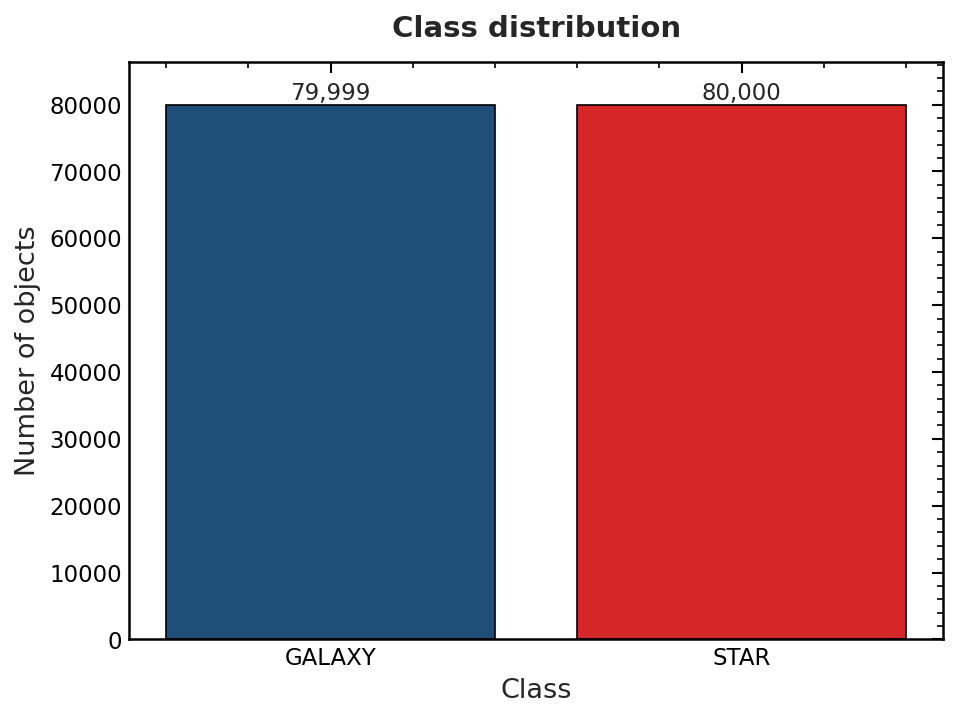

In [3]:
counts = df['class'].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c]['color'] for c in CLASSES],
              edgecolor='black', linewidth=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('Number of objects')
ax.set_title('Class distribution', fontweight='bold', pad=12)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, max(counts.values) * 1.08)
fig.savefig(RESULTS_DIR / 'class_distribution.png')
plt.show()

## Step 3 - Redshift distribution by class

The two populations occupy distinct redshift regimes: stars cluster near $z \approx 0$, galaxies dominate the low-to-mid range. 


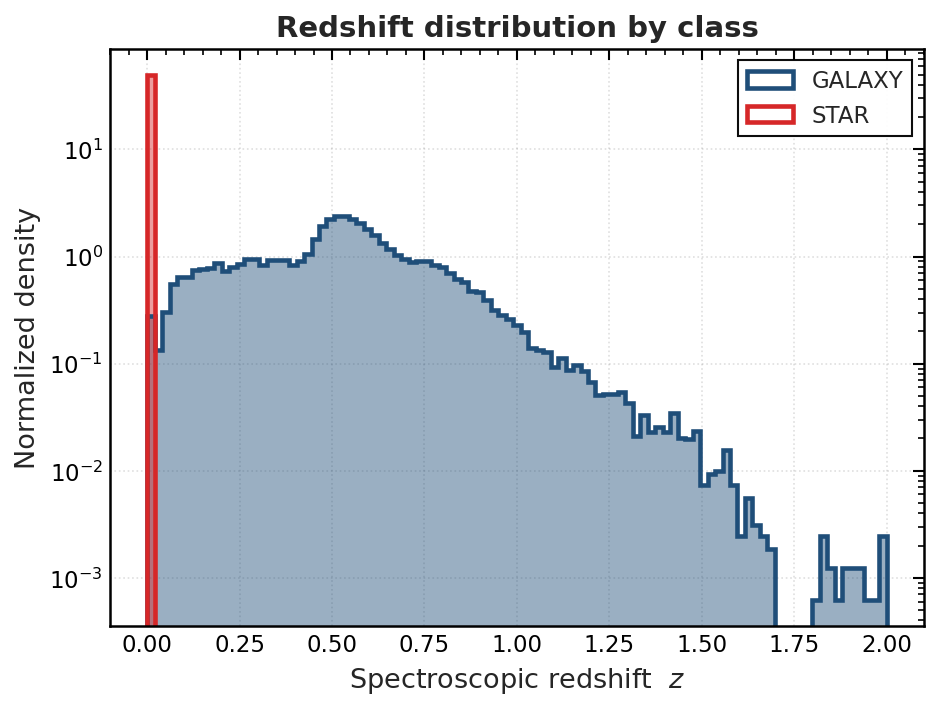

In [4]:
zmax = float(np.quantile(df['redshift'], 1.0))
bins = np.linspace(0, zmax, 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distribution by class')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend()
fig.savefig(RESULTS_DIR / 'redshift_distribution.png')
plt.show()


## Step 4 - Outer stratified split (POOL + TEST)

Single stratified outer split, identical seed and proportion to the SR companion. The 87.5% remainder is the **POOL** on which everything else operates - `GridSearchCV` and the CV-based reporting in Step 7. There is **no** inner TRAIN/VAL sub-split here. TEST stays at 12.5% with `random_state=42`, so the held-out rows are bit-for-bit the same as the SR notebook's TEST.

In [5]:
X = df[['redshift']].values.astype(float)
y = df['y_ord'].values.astype(int)

# --- Outer split: pool (87.5%) + TEST (12.5%) ---
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=0.125, random_state=RANDOM_STATE, stratify=y,
)

def _per_class_counts(y_arr):
    s = pd.Series(y_arr).map(ORD_TO_LABEL)
    return s.value_counts().reindex(CLASSES).astype(int)

total = len(y)
print(f'Total rows           : {total:,}')
print(f'POOL  (~87.5%)       : {len(y_pool):,}   ({100*len(y_pool)/total:.2f}%)')
print(f'TEST  (~12.5%)       : {len(y_test):,}   ({100*len(y_test)/total:.2f}%)')
print()
print('Per-class counts in POOL:'); print(_per_class_counts(y_pool))
print()
print('Per-class counts in TEST:'); print(_per_class_counts(y_test))

Total rows           : 159,999
POOL  (~87.5%)       : 139,999   (87.50%)
TEST  (~12.5%)       : 20,000   (12.50%)

Per-class counts in POOL:
GALAXY    69999
STAR      70000
Name: count, dtype: int64

Per-class counts in TEST:
GALAXY    10000
STAR      10000
Name: count, dtype: int64


## Step 5 - Define models and parameter grids

Three estimators with very small grids that **include paper-like defaults** as one combination each:

- **RF**: `{n_estimators: [100, 200], max_depth: [5, 10, None], min_samples_leaf: [1, 3]}` -> 12 combos. 
- **SVM**: `{C: [0.1, 1.0, 10.0], gamma: ['scale', '0.1']}` -> 6 combos. 
- **MLP**: `{hidden_layer_sizes: [(16,), (32,), (64, 32)], alpha: [1e-3, 1e-4], learning_rate_init: [1e-3]}` -> 6 combos. 



In [6]:
MODELS = {
    'Random Forest': (
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            'n_estimators':     [100, 200],
            'max_depth':        [5, 10, None],
            'min_samples_leaf': [1, 3],
        },
    ),
    'SVM': (
        SVC(
            kernel='rbf',
            cache_size=500,
            probability=True,
            random_state=RANDOM_STATE,
        ),
        {
            'C':     [0.1, 1.0, 10.0],
            'gamma': ['scale', '0.1'],
        },
    ),
    'MLP': (
        MLPClassifier(
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        {
            'hidden_layer_sizes':  [(16,), (32,), (32, 16)],
            'alpha':               [1e-3, 1e-4],
            'learning_rate_init':  [1e-3],
        },
    ),
}

for name, (est, grid) in MODELS.items():
    n_combos = int(np.prod([len(v) for v in grid.values()]))
    print(f'{name:>13s}: {n_combos} combos x {N_FOLDS} folds')

Random Forest: 12 combos x 5 folds
          SVM: 6 combos x 5 folds
          MLP: 6 combos x 5 folds


## Step 6 - GridSearchCV on the POOL

Stratified 5-fold inside `GridSearchCV`, `scoring='f1_macro'`, `refit=True`, `n_jobs=-1`. The grid search runs on the **full POOL** (`X_pool, y_pool`) for all three models. With `refit=True`, `gs.best_estimator_` returns the best-configuration estimator already refit on the entire pool, ready for direct deployment on TEST and EXTERNAL in Steps 8-9. Best hyper-parameters are persisted to JSON.

In [7]:
cv5 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

BEST_ESTIMATORS = {}
BEST_PARAMS     = {}

for name, (estimator, grid) in MODELS.items():
    print(f'\n=== {name}: GridSearchCV on POOL ({len(y_pool):,} rows) ===')

    gs = GridSearchCV(
        estimator, grid,
        cv=cv5, scoring='f1_macro',
        n_jobs=-1, refit=True,
    )
    gs.fit(X_pool, y_pool)

    BEST_ESTIMATORS[name] = gs.best_estimator_  # already refit on full POOL
    BEST_PARAMS[name]     = gs.best_params_

    print('   best CV f1_macro (POOL, 5-fold):', f'{gs.best_score_:.4f}')
    print('   best params:', gs.best_params_)

    serializable = {k: (list(v) if isinstance(v, tuple) else v) for k, v in gs.best_params_.items()}
    with open(RESULTS_DIR / f'{name}_best_params.json', 'w') as f:
        json.dump(serializable, f, indent=2)

print('\nAll models grid-searched on the same POOL; best_estimator_ already refit on POOL.')


=== Random Forest: GridSearchCV on POOL (139,999 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9979
   best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 200}

=== SVM: GridSearchCV on POOL (139,999 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9976
   best params: {'C': 10.0, 'gamma': 'scale'}

=== MLP: GridSearchCV on POOL (139,999 rows) ===
   best CV f1_macro (POOL, 5-fold): 0.9976
   best params: {'alpha': 0.0001, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001}

All models grid-searched on the same POOL; best_estimator_ already refit on POOL.


## Step 6b - Persist the trained models to disk

The three estimators in `BEST_ESTIMATORS` are `gs.best_estimator_` objects, which `GridSearchCV(refit=True)` has already refit on the **full POOL**. They are the final trained models: the per-fold loops in Step 8 (TEST) and Step 9 (EXTERNAL) both operate on `clone(best_est)` copies, so nothing downstream re-fits or mutates them.

Each is serialized to its own `.pkl` via `joblib` (the recommended serializer for scikit-learn estimators - same pickle protocol, but far more efficient for the large NumPy arrays inside the RF and MLP). Files land in `Ex1_MLAlgos_SG/saved_models/`.

Because the pipeline has **no preprocessing stage** - `X = df[['redshift']]` is fed to the estimators directly, exactly as `X_ext` is in Step 9 - a reloaded estimator is self-sufficient for inference:

```python
import joblib, numpy as np
model = joblib.load('Ex1_MLAlgos_SG/saved_models/random_forest_star_galaxy.pkl')
model.predict(np.array([[0.0004], [0.35]]))   # -> array([0, 1]) == [STAR, GALAXY]
```

Mind the label convention when interpreting output: `LABEL_TO_ORD = {'STAR': 0, 'GALAXY': 1}`, i.e. **0 = STAR, 1 = GALAXY** (this is deliberately *not* the alphabetical order of `CLASSES`). All three were fit with `probability=True` / native support, so `predict_proba` is available on reload as well.


In [8]:
# Step 6b - Save each trained model as its own .pkl (no retraining needed later)

import joblib

MODELS_DIR = RESULTS_DIR / 'saved_models'
MODELS_DIR.mkdir(exist_ok=True, parents=True)

# Descriptive, filesystem-safe filename per estimator
MODEL_FILENAMES = {
    'Random Forest': 'random_forest_star_galaxy.pkl',
    'SVM':           'svm_rbf_star_galaxy.pkl',
    'MLP':           'mlp_star_galaxy.pkl',
}

SAVED_MODEL_PATHS = {}

for name, model in BEST_ESTIMATORS.items():
    out_path = MODELS_DIR / MODEL_FILENAMES[name]
    joblib.dump(model, out_path, compress=3)
    SAVED_MODEL_PATHS[name] = out_path
    size_kb = out_path.stat().st_size / 1024
    print(f'{name:>13s} -> {out_path}  ({size_kb:,.1f} KiB)')

# --- Reload check: loaded models must reproduce the in-memory predictions ---
print('\nVerifying reloaded models...')
for name, model in BEST_ESTIMATORS.items():
    reloaded = joblib.load(SAVED_MODEL_PATHS[name])
    same_pred  = np.array_equal(reloaded.predict(X_test), model.predict(X_test))
    same_proba = np.allclose(reloaded.predict_proba(X_test), model.predict_proba(X_test))
    assert same_pred and same_proba, f'Reloaded {name} does not match the in-memory model'
    print(f'{name:>13s}: reload OK - predict and predict_proba match on TEST')

print(f'\nAll {len(SAVED_MODEL_PATHS)} trained models saved to {MODELS_DIR.resolve()}')


Random Forest -> Ex1_MLAlgos_SG/saved_models/random_forest_star_galaxy.pkl  (3,238.5 KiB)
          SVM -> Ex1_MLAlgos_SG/saved_models/svm_rbf_star_galaxy.pkl  (9.3 KiB)
          MLP -> Ex1_MLAlgos_SG/saved_models/mlp_star_galaxy.pkl  (18.2 KiB)

Verifying reloaded models...
Random Forest: reload OK - predict and predict_proba match on TEST
          SVM: reload OK - predict and predict_proba match on TEST
          MLP: reload OK - predict and predict_proba match on TEST

All 3 trained models saved to /home/srinadb/SGExperiments/Photo_Classification/SRFinal/Ex1_MLAlgos_SG/saved_models


## Step 7 - 5-fold CV on POOL (mean +/- std + CV confusion matrix)

For each best estimator, we run `cross_val_predict` and `cross_val_score` on the **POOL** with `StratifiedKFold(N_FOLDS=5, shuffle=True, random_state=42)`. The CV confusion matrix is row-normalized and annotated via `_pct_annot` (annot size 14); mean +/- std are reported for accuracy / precision_macro / recall_macro / f1_macro and saved to `<model>_cv_summary.csv`.


=== Random Forest: 5-fold CV on POOL (139,999 rows) ===


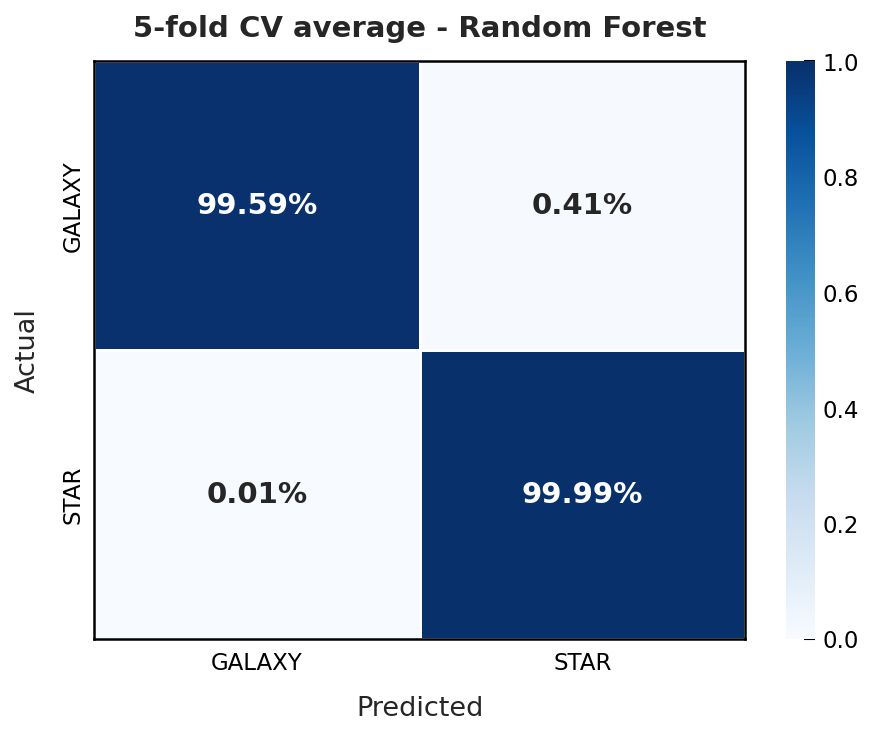

         metric   mean    std
       accuracy 0.9979 0.0002
precision_macro 0.9979 0.0002
   recall_macro 0.9979 0.0002
       f1_macro 0.9979 0.0002

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9959    0.9999    0.9979     70000
        STAR     0.9999    0.9959    0.9979     69999

    accuracy                         0.9979    139999
   macro avg     0.9979    0.9979    0.9979    139999
weighted avg     0.9979    0.9979    0.9979    139999


=== SVM: 5-fold CV on POOL (139,999 rows) ===


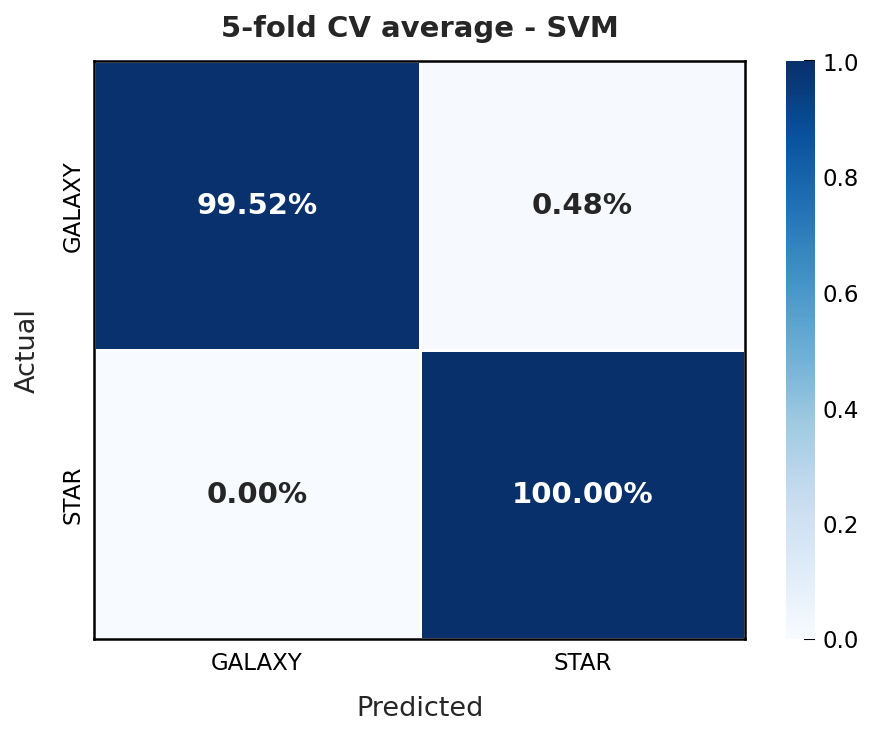

         metric   mean    std
       accuracy 0.9976 0.0002
precision_macro 0.9976 0.0002
   recall_macro 0.9976 0.0002
       f1_macro 0.9976 0.0002

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9952    1.0000    0.9976     70000
        STAR     1.0000    0.9952    0.9976     69999

    accuracy                         0.9976    139999
   macro avg     0.9976    0.9976    0.9976    139999
weighted avg     0.9976    0.9976    0.9976    139999


=== MLP: 5-fold CV on POOL (139,999 rows) ===


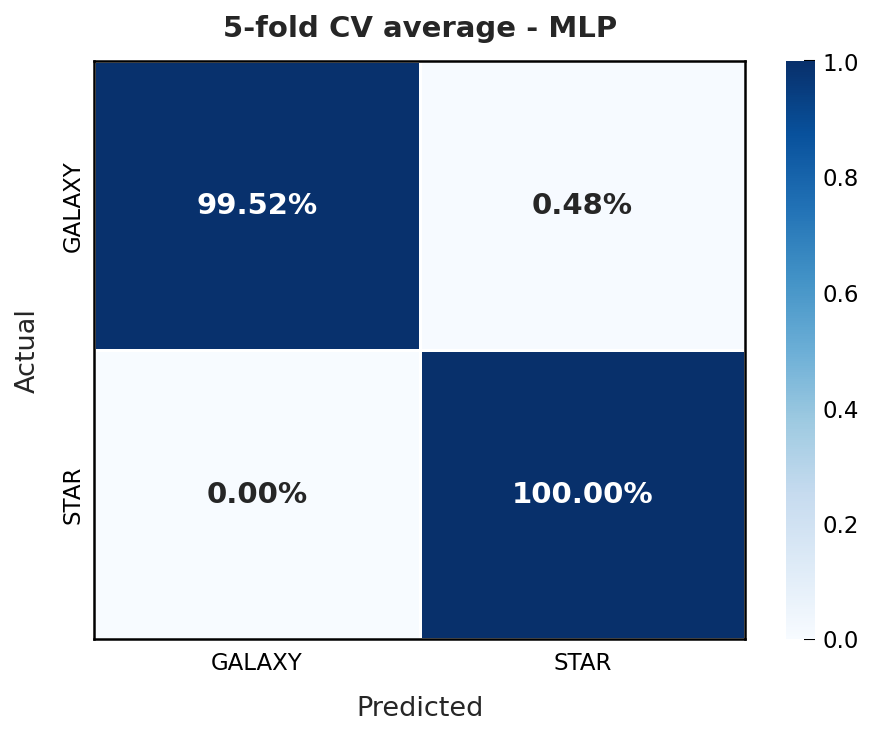

         metric   mean    std
       accuracy 0.9976 0.0001
precision_macro 0.9976 0.0001
   recall_macro 0.9976 0.0001
       f1_macro 0.9976 0.0001

Classification report (cross_val_predict on POOL):
              precision    recall  f1-score   support

      GALAXY     0.9952    1.0000    0.9976     70000
        STAR     1.0000    0.9952    0.9976     69999

    accuracy                         0.9976    139999
   macro avg     0.9976    0.9976    0.9976    139999
weighted avg     0.9976    0.9976    0.9976    139999



In [9]:
cv_scoring = {
    'accuracy':        'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro':    'recall_macro',
    'f1_macro':        'f1_macro',
}

cv_summary_rows = []

for name, model in BEST_ESTIMATORS.items():
    print(f'\n=== {name}: 5-fold CV on POOL ({len(y_pool):,} rows) ===')

    y_cv_pred = cross_val_predict(
        model, X_pool, y_pool,
        cv=cv5, n_jobs=-1,
    )

    cm_cv_count = confusion_matrix(y_pool, y_cv_pred, labels=LABEL_ORDER)
    cm_cv_norm  = cm_cv_count / cm_cv_count.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    sns.heatmap(cm_cv_norm, annot=_pct_annot(cm_cv_norm), fmt='', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=True, vmin=0, vmax=1,
                annot_kws={'size': 14, 'weight': 'bold'},
                linewidths=0.6, linecolor='white')
    _style_cm_axes(ax, f'5-fold CV average - {name}')
    fig.savefig(RESULTS_DIR / f'confusion_matrix_cv_{name}.png')
    plt.show()

    per_metric = {}
    for metric_name, metric_key in cv_scoring.items():
        scores = cross_val_score(
            model, X_pool, y_pool,
            cv=cv5, scoring=metric_key, n_jobs=-1,
        )
        per_metric[metric_name] = {
            'mean':   float(np.mean(scores)),
            'std':    float(np.std(scores, ddof=0)),
            'scores': [float(s) for s in scores],
        }

    summary_df = pd.DataFrame({
        'metric': list(per_metric.keys()),
        'mean':   [per_metric[m]['mean'] for m in per_metric],
        'std':    [per_metric[m]['std']  for m in per_metric],
    })
    summary_df.to_csv(RESULTS_DIR / f'{name}_cv_summary.csv', index=False)

    per_metric_df = pd.DataFrame(
        {m: per_metric[m]['scores'] for m in per_metric},
        index=[f'fold_{i+1}' for i in range(N_FOLDS)],
    )
    per_metric_df.to_csv(RESULTS_DIR / f'{name}_cv_per_metric.csv')

    print(summary_df.to_string(index=False, formatters={
        'mean': '{:.4f}'.format, 'std': '{:.4f}'.format,
    }))
    print('\nClassification report (cross_val_predict on POOL):')
    print(classification_report(
        y_pool, y_cv_pred,
        labels=[0, 1], target_names=CLASSES, digits=4, zero_division=0,
    ))

    cv_summary_rows.append({
        'model':           name,
        'cv_accuracy':     per_metric['accuracy']['mean'],
        'cv_accuracy_std': per_metric['accuracy']['std'],
        'cv_f1_macro':     per_metric['f1_macro']['mean'],
        'cv_f1_macro_std': per_metric['f1_macro']['std'],
    })

## Step 8 - TEST evaluation 




=== Random Forest: TEST (headline + per-fold std) ===
accuracy        : 0.9978
precision_macro : 0.9978
recall_macro    : 0.9978
f1_macro        : 0.9977

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9957    0.9998    0.9978     10000
        STAR     0.9998    0.9957    0.9977     10000

    accuracy                         0.9978     20000
   macro avg     0.9978    0.9978    0.9977     20000
weighted avg     0.9978    0.9978    0.9977     20000



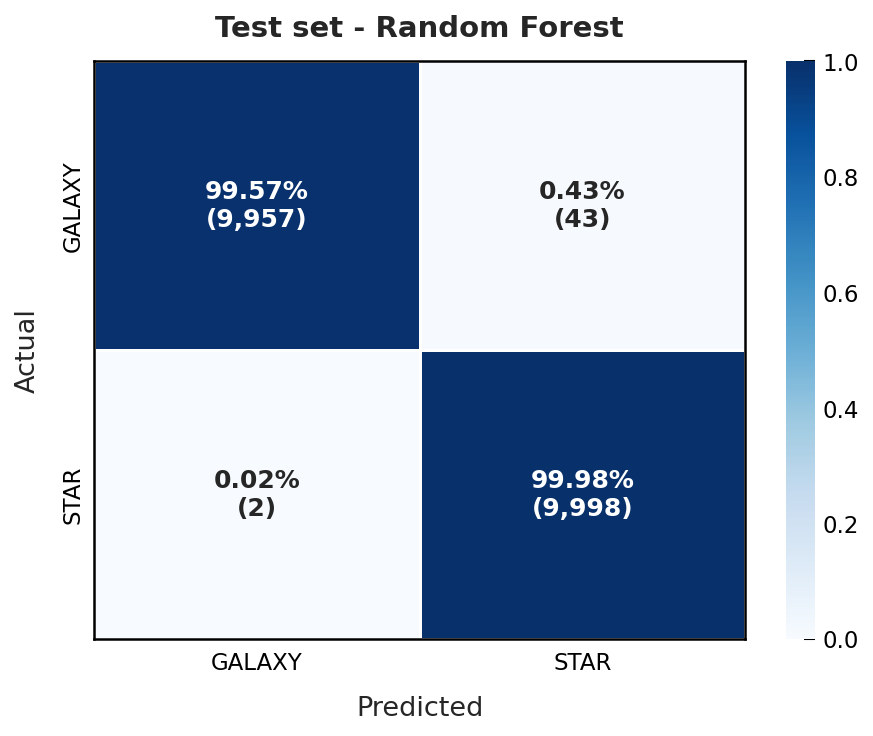


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9978 0.0001
precision_macro 0.9978 0.0001
   recall_macro 0.9978 0.0001
       f1_macro 0.9978 0.0001

=== SVM: TEST (headline + per-fold std) ===
accuracy        : 0.9974
precision_macro : 0.9974
recall_macro    : 0.9974
f1_macro        : 0.9974

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9948    1.0000    0.9974     10000
        STAR     1.0000    0.9948    0.9974     10000

    accuracy                         0.9974     20000
   macro avg     0.9974    0.9974    0.9974     20000
weighted avg     0.9974    0.9974    0.9974     20000



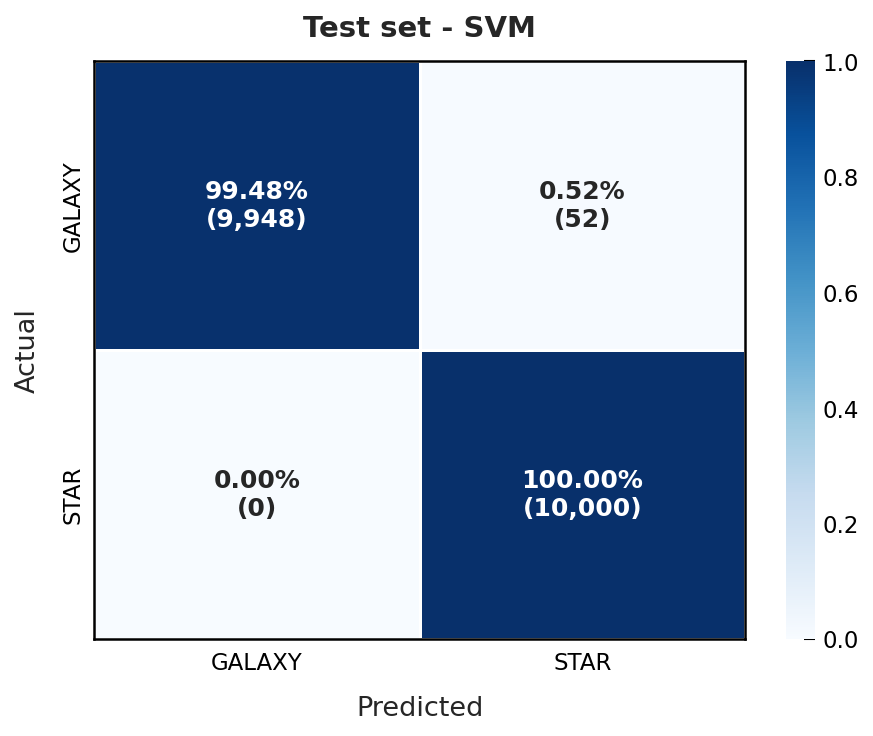


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9974 0.0000
precision_macro 0.9974 0.0000
   recall_macro 0.9974 0.0000
       f1_macro 0.9974 0.0000

=== MLP: TEST (headline + per-fold std) ===
accuracy        : 0.9973
precision_macro : 0.9973
recall_macro    : 0.9973
f1_macro        : 0.9973

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9946    1.0000    0.9973     10000
        STAR     1.0000    0.9946    0.9973     10000

    accuracy                         0.9973     20000
   macro avg     0.9973    0.9973    0.9973     20000
weighted avg     0.9973    0.9973    0.9973     20000



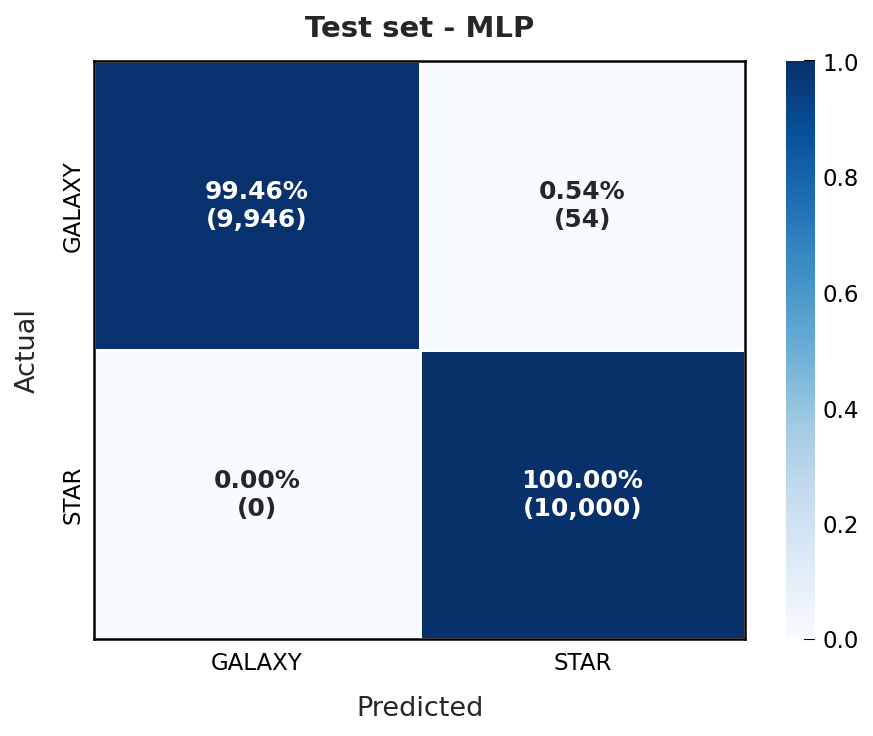


TEST mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9973 0.0001
precision_macro 0.9973 0.0001
   recall_macro 0.9973 0.0001
       f1_macro 0.9973 0.0001


In [10]:
test_summary_rows = []

for name, best_est in BEST_ESTIMATORS.items():
    print(f'\n=== {name}: TEST (headline + per-fold std) ===')

    # --- Headline: predict TEST with gs.best_estimator_ (refit on POOL) ---
    y_pred = best_est.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    f1m  = f1_score(y_test, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)

    print(f'accuracy        : {acc:.4f}')
    print(f'precision_macro : {prec:.4f}')
    print(f'recall_macro    : {rec:.4f}')
    print(f'f1_macro        : {f1m:.4f}')
    print('\nclassification_report:')
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1], target_names=CLASSES, digits=4, zero_division=0,
    ))

    metrics_df = pd.DataFrame({
        'metric': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        'value':  [acc, prec, rec, f1m],
    })
    metrics_df.to_csv(RESULTS_DIR / f'{name}_test_metrics.csv', index=False)

    cm_count = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    cm_norm  = cm_count / cm_count.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    sns.heatmap(cm_norm, annot=_pct_count_annot(cm_norm, cm_count), fmt='', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=True, vmin=0, vmax=1,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.6, linecolor='white')
    _style_cm_axes(ax, f'Test set - {name}')
    fig.savefig(RESULTS_DIR / f'confusion_matrix_test_{name}.png')
    plt.show()

    # --- Per-fold std on TEST: refit on each fold's tr_idx, predict TEST ---
    fold_rows = []
    for fi, (tr_idx, _) in enumerate(cv5.split(X_pool, y_pool), start=1):
        fold_est = clone(best_est)
        fold_est.fit(X_pool[tr_idx], y_pool[tr_idx])
        yp_f = fold_est.predict(X_test)
        fold_rows.append({
            'fold':            fi,
            'accuracy':        accuracy_score(y_test, yp_f),
            'precision_macro': precision_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'recall_macro':    recall_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'f1_macro':        f1_score(y_test, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
        })
    fold_df = pd.DataFrame(fold_rows)
    fold_df.to_csv(RESULTS_DIR / f'{name}_test_per_fold.csv', index=False)

    metric_cols = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    std_summary_df = pd.DataFrame({
        'metric': metric_cols,
        'mean':   [fold_df[m].mean() for m in metric_cols],
        'std':    [fold_df[m].std(ddof=1) for m in metric_cols],
    })
    std_summary_df.to_csv(RESULTS_DIR / f'{name}_test_metrics_with_std.csv', index=False)
    print('\nTEST mean +/- std across 5 fold-refits:')
    print(std_summary_df.to_string(index=False, formatters={
        'mean': '{:.4f}'.format, 'std': '{:.4f}'.format,
    }))

    test_summary_rows.append({
        'model':                name,
        'test_accuracy':        acc,
        'test_precision_macro': prec,
        'test_recall_macro':    rec,
        'test_f1_macro':        f1m,
        'test_accuracy_std':    fold_df['accuracy'].std(ddof=1),
        'test_f1_macro_std':    fold_df['f1_macro'].std(ddof=1),
    })

## Step 9 - EXTERNAL evaluation 


External catalog: 19,022 rows (binary, QSO dropped)
class
GALAXY    9511
STAR      9511
Name: count, dtype: int64

=== Random Forest: EXTERNAL (headline + per-fold std) ===
accuracy        : 0.9993
precision_macro : 0.9993
recall_macro    : 0.9993
f1_macro        : 0.9993

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9985    1.0000    0.9993      9511
        STAR     1.0000    0.9985    0.9993      9511

    accuracy                         0.9993     19022
   macro avg     0.9993    0.9993    0.9993     19022
weighted avg     0.9993    0.9993    0.9993     19022



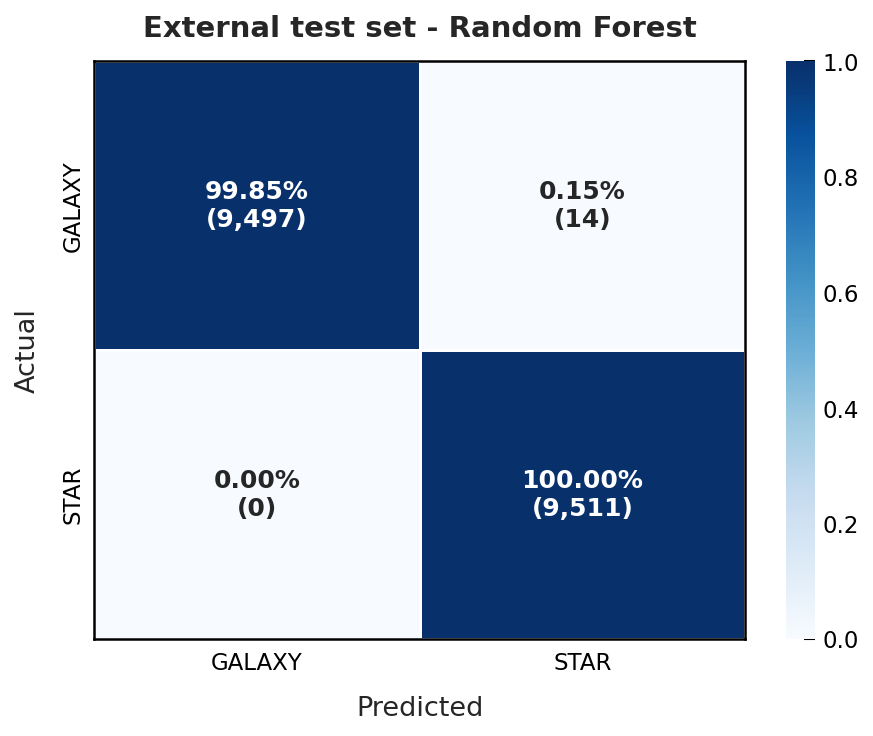


EXTERNAL mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9992 0.0000
precision_macro 0.9992 0.0000
   recall_macro 0.9992 0.0000
       f1_macro 0.9992 0.0000

=== SVM: EXTERNAL (headline + per-fold std) ===
accuracy        : 0.9989
precision_macro : 0.9989
recall_macro    : 0.9989
f1_macro        : 0.9989

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9978    1.0000    0.9989      9511
        STAR     1.0000    0.9978    0.9989      9511

    accuracy                         0.9989     19022
   macro avg     0.9989    0.9989    0.9989     19022
weighted avg     0.9989    0.9989    0.9989     19022



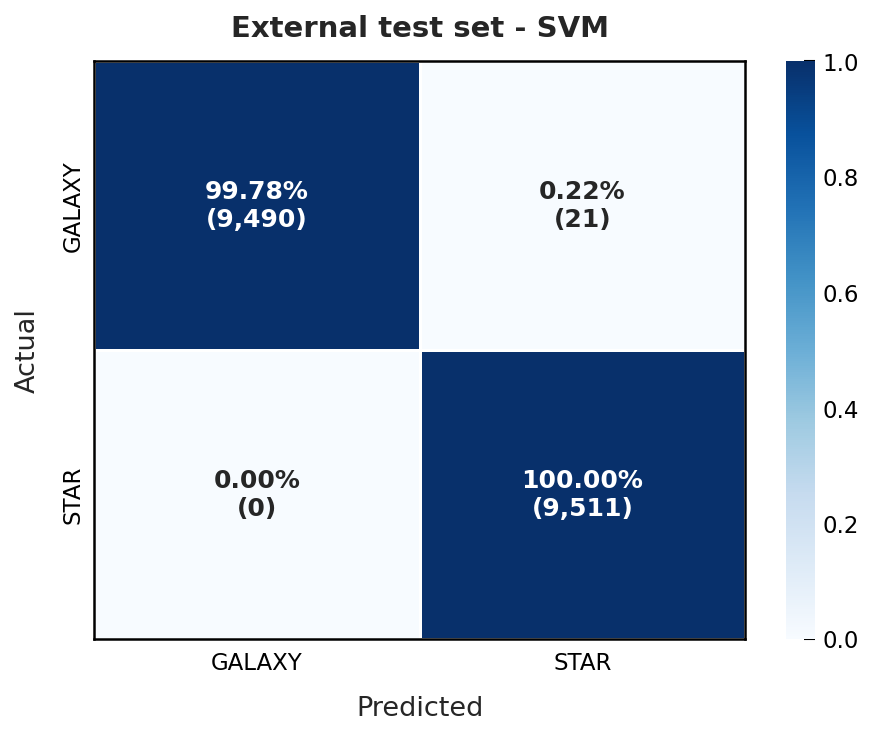


EXTERNAL mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9989 0.0000
precision_macro 0.9989 0.0000
   recall_macro 0.9989 0.0000
       f1_macro 0.9989 0.0000

=== MLP: EXTERNAL (headline + per-fold std) ===
accuracy        : 0.9988
precision_macro : 0.9988
recall_macro    : 0.9988
f1_macro        : 0.9988

classification_report:
              precision    recall  f1-score   support

      GALAXY     0.9977    1.0000    0.9988      9511
        STAR     1.0000    0.9977    0.9988      9511

    accuracy                         0.9988     19022
   macro avg     0.9988    0.9988    0.9988     19022
weighted avg     0.9988    0.9988    0.9988     19022



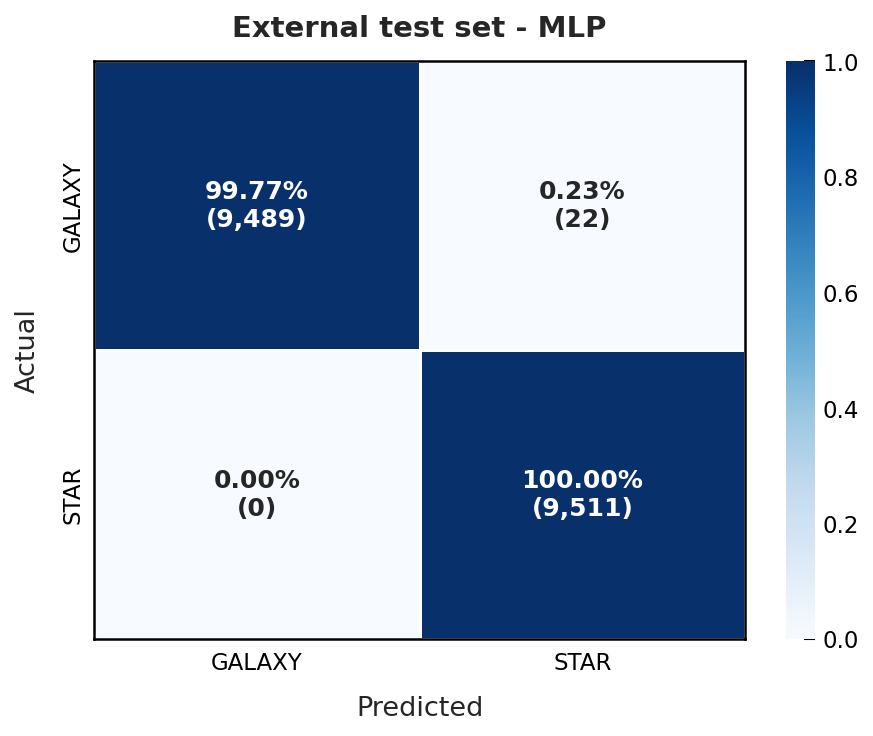


EXTERNAL mean +/- std across 5 fold-refits:
         metric   mean    std
       accuracy 0.9989 0.0000
precision_macro 0.9989 0.0000
   recall_macro 0.9989 0.0000
       f1_macro 0.9989 0.0000


In [11]:
EXT_CSV_PATH = 'photofeatures_exp3.csv'
df_ext = pd.read_csv(EXT_CSV_PATH)
df_ext['class'] = df_ext['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df_ext = df_ext.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df_ext = df_ext[df_ext['class'].isin(CLASSES)].reset_index(drop=True)  # drops QSO -> binary
df_ext['y_ord'] = df_ext['class'].map(LABEL_TO_ORD).astype(int)

X_ext = df_ext[['redshift']].values.astype(float)
y_ext = df_ext['y_ord'].values.astype(int)

print('External catalog:', f'{len(df_ext):,} rows (binary, QSO dropped)')
print(df_ext['class'].value_counts().reindex(CLASSES))

ext_summary_rows = []

for name, best_est in BEST_ESTIMATORS.items():
    print(f'\n=== {name}: EXTERNAL (headline + per-fold std) ===')

    # --- Headline: predict EXTERNAL with gs.best_estimator_ ---
    y_pred = best_est.predict(X_ext)

    acc  = accuracy_score(y_ext, y_pred)
    prec = precision_score(y_ext, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    rec  = recall_score(y_ext, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
    f1m  = f1_score(y_ext, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)

    print(f'accuracy        : {acc:.4f}')
    print(f'precision_macro : {prec:.4f}')
    print(f'recall_macro    : {rec:.4f}')
    print(f'f1_macro        : {f1m:.4f}')
    print('\nclassification_report:')
    print(classification_report(
        y_ext, y_pred,
        labels=[0, 1], target_names=CLASSES, digits=4, zero_division=0,
    ))

    metrics_df = pd.DataFrame({
        'metric': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        'value':  [acc, prec, rec, f1m],
    })
    metrics_df.to_csv(RESULTS_DIR / f'{name}_external_metrics.csv', index=False)

    cm_count = confusion_matrix(y_ext, y_pred, labels=LABEL_ORDER)
    cm_norm  = cm_count / cm_count.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    sns.heatmap(cm_norm, annot=_pct_count_annot(cm_norm, cm_count), fmt='', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=True, vmin=0, vmax=1,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.6, linecolor='white')
    _style_cm_axes(ax, f'External test set - {name}')
    fig.savefig(RESULTS_DIR / f'confusion_matrix_external_{name}.png')
    plt.show()

    # --- Per-fold std on EXTERNAL ---
    fold_rows = []
    for fi, (tr_idx, _) in enumerate(cv5.split(X_pool, y_pool), start=1):
        fold_est = clone(best_est)
        fold_est.fit(X_pool[tr_idx], y_pool[tr_idx])
        yp_f = fold_est.predict(X_ext)
        fold_rows.append({
            'fold':            fi,
            'accuracy':        accuracy_score(y_ext, yp_f),
            'precision_macro': precision_score(y_ext, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'recall_macro':    recall_score(y_ext, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
            'f1_macro':        f1_score(y_ext, yp_f, labels=LABEL_ORDER, average='macro', zero_division=0),
        })
    fold_df = pd.DataFrame(fold_rows)
    fold_df.to_csv(RESULTS_DIR / f'{name}_external_per_fold.csv', index=False)

    metric_cols = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    std_summary_df = pd.DataFrame({
        'metric': metric_cols,
        'mean':   [fold_df[m].mean() for m in metric_cols],
        'std':    [fold_df[m].std(ddof=1) for m in metric_cols],
    })
    std_summary_df.to_csv(RESULTS_DIR / f'{name}_external_metrics_with_std.csv', index=False)
    print('\nEXTERNAL mean +/- std across 5 fold-refits:')
    print(std_summary_df.to_string(index=False, formatters={
        'mean': '{:.4f}'.format, 'std': '{:.4f}'.format,
    }))

    ext_summary_rows.append({
        'model':               name,
        'ext_accuracy':        acc,
        'ext_precision_macro': prec,
        'ext_recall_macro':    rec,
        'ext_f1_macro':        f1m,
        'ext_accuracy_std':    fold_df['accuracy'].std(ddof=1),
        'ext_f1_macro_std':    fold_df['f1_macro'].std(ddof=1),
    })

## Step 10 - Summary table

Consolidated CV / TEST / EXTERNAL accuracy and macro-F1 for RF, SVM, MLP, with std columns where applicable. Use this as the side-by-side comparison against the SR companion's `summary_metrics.csv`.

In [12]:
cv_df   = pd.DataFrame(cv_summary_rows).set_index('model')
test_df = pd.DataFrame(test_summary_rows).set_index('model')
ext_df  = pd.DataFrame(ext_summary_rows).set_index('model')

summary_df = pd.concat([cv_df, test_df, ext_df], axis=1).reset_index()
summary_df = summary_df[[
    'model',
    'cv_accuracy', 'cv_accuracy_std', 'cv_f1_macro', 'cv_f1_macro_std',
    'test_accuracy', 'test_accuracy_std', 'test_f1_macro', 'test_f1_macro_std',
    'ext_accuracy', 'ext_accuracy_std', 'ext_f1_macro', 'ext_f1_macro_std',
]]

summary_df.to_csv(RESULTS_DIR / 'summary_all_models.csv', index=False)

fmts = {c: '{:.4f}'.format for c in summary_df.columns if c != 'model'}
print(summary_df.to_string(index=False, formatters=fmts))

        model cv_accuracy cv_accuracy_std cv_f1_macro cv_f1_macro_std test_accuracy test_accuracy_std test_f1_macro test_f1_macro_std ext_accuracy ext_accuracy_std ext_f1_macro ext_f1_macro_std
Random Forest      0.9979          0.0002      0.9979          0.0002        0.9978            0.0001        0.9977            0.0001       0.9993           0.0000       0.9993           0.0000
          SVM      0.9976          0.0002      0.9976          0.0002        0.9974            0.0000        0.9974            0.0000       0.9989           0.0000       0.9989           0.0000
          MLP      0.9976          0.0001      0.9976          0.0001        0.9973            0.0001        0.9973            0.0001       0.9988           0.0000       0.9988           0.0000
